### Deep Agents overview



Build agents that can plan, use subagents, and leverage file systems for complex tasks

deepagents is a standalone library for building agents that can tackle complex, multi-step tasks. Built on LangGraph and inspired by applications like Claude Code, Deep Research, and Manus, deep agents come with planning capabilities, file systems for context management, and the ability to spawn subagents.


### When to use deep agents
Use deep agents when you need agents that can:

- Handle complex, multi-step tasks that require planning and decomposition
- Manage large amounts of context through file system tools
- Delegate work to specialized subagents for context isolation
- Persist memory across conversations and threads

In [1]:
### Basic deep agent

import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
# Gemini: langchain-google-genai reads GOOGLE_API_KEY
os.environ["GOOGLE_API_KEY"]=os.getenv("GEMINI_API_KEY")

In [2]:
from typing import Literal

In [3]:
### Tools- Internet search
from tavily import TavilyClient
from typing import Literal

tavily_client=TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))

def web_search(query:str,max_results:int=5,
topic: Literal["general","sports","news","finance"]="general",
include_raw_content:bool=False):
    """Run a web search"""
    return tavily_client.search(query,
    max_results=max_results,include_raw_content=include_raw_content,topic=topic)



In [4]:
from langchain.chat_models import init_chat_model

model=init_chat_model("google_genai:gemini-2.5-flash")
model

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


ChatGoogleGenerativeAI(output_version=None, profile={'name': 'Gemini 2.5 Flash', 'release_date': '2025-03-20', 'last_updated': '2025-06-05', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), location=None, model='gemini-2.5-flash', client=<google.genai.client.Client object at 0x115d2a6f0>, default_metadata=(), model_kwargs={})

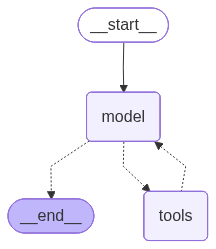

In [5]:
## Basic Agent
from langchain.agents import create_agent


simple_agent=create_agent(
    model=model,
    tools=[web_search]
)
simple_agent

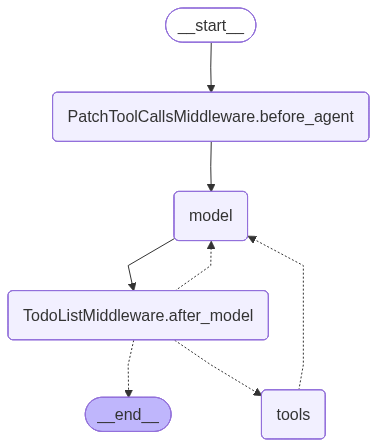

In [6]:
### Create a deep agent
## Prompt

## agent

from deepagents import create_deep_agent

deepagent=create_deep_agent(
    model=model,
    tools=[web_search],
    system_prompt="Act as a researcher"
)
deepagent

In [7]:
result = deepagent.invoke({"messages": [{"role": "user", "content": "What is deepagent?"}]})
result

{'messages': [HumanMessage(content='What is deepagent?', additional_kwargs={}, response_metadata={}, id='7f80d8b6-bd79-4cc5-9614-002be8c9ddc5'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'web_search', 'arguments': '{"query": "what is deepagent"}'}, '__gemini_function_call_thought_signatures__': {'414ddc27-9f0a-4d72-8a96-e05813c510f5': 'CvABAQw51sdBp/rHn8vTvhtIsuOTydmpYQC0vf+Pw47ECt83ddCbaGZzHaHaLhgJ3WuqYiWeL05UivlYcb8kMiG+ySd+DbcXx0CRbKmA5culn6HFBqDMfPeylvK7E6owcWL+fV4IGb6/aalcMZTz1jWGs/OOyyduPO9takMs1xiK8O1DqhFRT22EtgzAhrWiqOhfr+geTq0do0MedXXr2J4vK6b+XAXJRBggxzb/bLsCeHu+oEMzt8g6lZe5z2KxeUSldsptZALESILRaY7Me2LP5iAogZTrSvE86OYXazt73khm85yIApSSN6j1NkLPHMu7'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e67b7-6649-76b1-98ec-57fc01a831e9-0', tool_calls=[{'name': 'web_search', 'args': {'query': 'what is deepagent'}, 'id': '414ddc27-9f0a-4d72-8a96-e05813c510f5

In [8]:
result["messages"][-1].content

[{'type': 'text',
  'text': 'DeepAgent can refer to:\n\n*   An AI super agent from Abacus AI that automates tasks like web app creation, presentations, and research, and can test applications using a virtual computer.\n*   An AI-powered agent studio by GoZen that automates sales, support, and marketing processes.\n*   A concept within the LangChain SDK for building AI agents capable of handling complex, multi-step tasks, utilizing subagents for context isolation and reusable skills.',
  'extras': {'signature': 'CtgHAQw51seZ4+6BkTXZLBGeRw3ron1DqZbVOaiRHmjVXpUBnAChAHvkAONtQbu+hu+qW6PI3ca9IaGphOwjmce7rSKaZydPMB9t8oAVzP/0+iTdChCRuU9JQLBYVkRoAIjDe771IO2Ob0Rmx8IOYG7YjLD3OpHljpBVm4vINOf1p2dJscpkStC7r/bKARHmv4+AFiC741i8uvL5wQOQ4eATP5ZHK6ZEjy54ZL14EtpEyb2541len1z1e3wFv9aq/0kSCq5vvzhbs/Gh4Q9Md392RtgoC3weIICh39zzS2m8WMrucynnXBQ6IZnhZxUbO1hjICqxpoedEeP0OWTlpB/3PNh68fpnR5c+TnsnrDuTdz62NrZL2hTjY0B8px7RwGqhs1A1xcjdT9w0T9uxA6xA6So6/gFaq77R/4xOEzIBuegsb9fL0Nks1lND28vdWOmDPF4nZxmnD5aDP4AuRuCako4cKVNWEGn

In [9]:
result['files']

{}

### What happened?

Your deep agent automatically:
- Planned its approach: Used the built-in write_todos tool to break down the research task
- Conducted research: Called the internet_search tool to gather information
- Managed context: Used file system tools (write_file, read_file) to offload large search results
- Spawned subagents (if needed): Delegated complex subtasks to specialized subagents
- Synthesized a report: Compiled findings into a coherent response

### Customizing Deep Agents

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


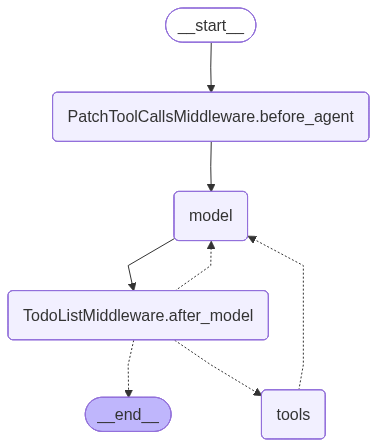

In [10]:
## #Model
from langchain.chat_models import init_chat_model
from deepagents import create_deep_agent

model = init_chat_model("google_genai:gemini-2.5-flash")
agent = create_deep_agent(model=model)
agent

In [11]:
result = agent.invoke({"messages": [{"role": "user", "content": "What is deepagent?"}]})
result

{'messages': [HumanMessage(content='What is deepagent?', additional_kwargs={}, response_metadata={}, id='47056039-bd7c-4a5a-a5c7-e8f4320c83b2'),
  AIMessage(content=[{'type': 'text', 'text': "A deep agent is an AI assistant that uses tools to accomplish tasks, interacting with users and providing responses and tool outputs in real time. It's designed to be concise, direct, and to prioritize accuracy. It can plan complex objectives using a to-do list, interact with a filesystem, and launch subagents for isolated tasks.", 'extras': {'signature': 'CuYBAQw51sfPzFi2voNbXRP8lRM+P58ESNfkDIWOqqroHqXQudz+PiDQ18yIPhmd4MX7OUdJ2x2ACz9RJlVRIv881otsp/5NwJjWudc8SePiAtTGdvzRiJdPy6DV6PgsvrSxQV9CjixvfKEsPhod21Faakw28+P7r1y5JzESBji2WpEzNCB8ZvAh3c2XQvK3dadr2vWBnBB+FR/C5zfcc1VxlP8df3eHpY30AZqLyOM9qMy86P3gFKD0AhDFATPvrYktghQIuTVUfgkf5GvAEkdy9txT5CyiaVp3XbU+m+C4TTqnVot0R38='}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_pr

### System Prompt
Deep agents come with a built-in system prompt inspired by Claude Code’s system prompt. The default system prompt contains detailed instructions for using the built-in planning tool, file system tools, and subagents.
Each deep agent tailored to a use case should include a custom system prompt specific to that use case.

In [12]:
from deepagents import create_deep_agent

research_instructions = """\
You are an expert researcher. Your job is to conduct \
thorough research, and then write a polished report. \
"""

agent = create_deep_agent(
    model=model,
    system_prompt=research_instructions,
)
result = agent.invoke({"messages": [{"role": "user", "content": "What is deepagent?"}]})
result

{'messages': [HumanMessage(content='What is deepagent?', additional_kwargs={}, response_metadata={}, id='3aaf3bf0-084b-4e5f-9921-dd73fc45b50b'),
  AIMessage(content=[{'type': 'text', 'text': 'A deep agent is an AI assistant that uses tools to accomplish tasks. It operates by understanding a request, using available tools to perform the necessary actions, and then verifying its work. Deep agents are designed to be concise, objective, and efficient in completing tasks, often breaking down complex objectives into smaller, manageable steps, and utilizing subagents for isolated, multi-step tasks.', 'extras': {'signature': 'CpEDAQw51seLNnVR2xQRVDLHwXLMO1KoDF3DYBKkgjuSZmP/3wBYkhWbeZ5eW8nNhQED5+VUbKqpINZZAB+kb4X6hMovwN0R0iTmJx3zsgF+gcRWvCHbDg2B/5Sf1LOBe7wVZkqX7Qtj/an2rKZLryrU9M46Kn+sfAarHDtZtf5jMJmaALGttwOKWGUyckTHI9nlNFJWcL2xyP2KGTzKezrAKSjcLQBySxZBCj01LgHZq5yVoXlaEoFnC6OO0PC2FyFX6jHNFNEvI2FVeQ5nb7R1bXkBelxYa1nNQvQBThs2BN0XelEqtlsHFAwcfuu+ER64H4961a8Q5JAq8PitZ2fMtIBllUwae1S/CYHbS2FirODD61IBGd

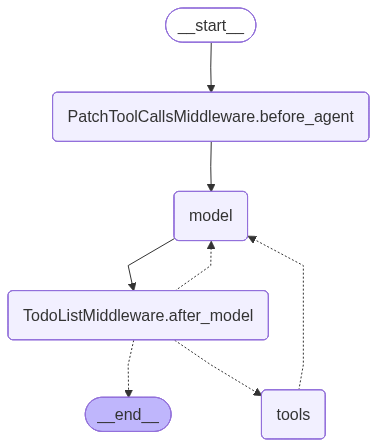

In [13]:
agent

In [14]:
### Tools
import os
from typing import Literal
from tavily import TavilyClient
from deepagents import create_deep_agent

tavily_client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])

def internet_search(
    query: str,
    max_results: int = 5,
    topic: Literal["general", "news", "finance"] = "general",
    include_raw_content: bool = False,
):
    """Run a web search"""
    return tavily_client.search(
        query,
        max_results=max_results,
        include_raw_content=include_raw_content,
        topic=topic,
    )

agent = create_deep_agent(
    model=model,
    tools=[internet_search]
)
result = agent.invoke({"messages": [{"role": "user", "content": "What is deepagent in Agentic AI?"}]})
result

{'messages': [HumanMessage(content='What is deepagent in Agentic AI?', additional_kwargs={}, response_metadata={}, id='ab6505b9-e98b-419e-b523-5d99e713fbb4'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'internet_search', 'arguments': '{"query": "deepagent in Agentic AI"}'}, '__gemini_function_call_thought_signatures__': {'e1e8907f-6a62-4731-9d81-80f6b897b653': 'CpECAQw51se5NYcV86JwaXBwU5kt1dDrT1U0RHtC2RaJ/euOkCSyDLuEFYJUrEb2ZTvuH1ewlkPPfvDI0REGAPttUZEOAP8+gktTwiX0C5ZXPgqANLfjeBHllgYPGkfpvNn6n8CEozrlEKt12adQmc6JyMFROylfocRNyaT1e3dGR1GMl6UjtTB/JMyu++HL+tcOozlqtrHsYoSJveBf4sqHaTlhLsvvXF5ZNiJXsPHI176puyzSUPdIyyyuCXW3vOi3A7WWIXJYs6biHDN4fM4IvTzOVpmlyWVv8AH3DBXDA7vPVvVH0Y3Mzr4cXak+Q3tjoartNsz0eXOuPTjUXJ8tDSx0Y5WqR1UJXliBDX3DJUSb'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e67b7-96a1-7770-bd5e-89e2dc950ad3-0', tool_calls=[{'name': 'internet_search', 'args': {